# Lab 1

 This lab is designed to introduce Gaussian processes in a practical way, illustrating the concepts introduced in the first two lectures. The key aspects of Gaussian process regression are covered: the covariance function (aka kernels); sampling a Gaussian process; and the regression model. The notebook will introduce the Python library `GPy`$^\dagger$ which handles the kernels, regression and optimisation of hyperparameter, allowing us to easily access the results we want.

The level of this notebook is aimed at introductory, as the background of attendees is diverse, and so cover a wide range of basic GP concepts. There are seven exercises to complete, the difficulty of which varies, but you should aim to complete all during the lab session. The notebook will not be marked and we will provide answers to the exercises after the lab session.

$^\dagger$`GPy`: A Gaussian process framework in Python (since 2012). Available from http://github.com/SheffieldML/GPy

**This lab has been modified from the original version made for the Gaussian process summer school 2022 at the University of Sheffield.**


## 1. Getting started

First, we need to setup our notebook with the libraries we are going to use. We will use `numpy` for maths functionality, `pyplot` for plotting, and of course `GPy` for Gaussian processes.

In [2]:
# Install prerequisite packages
!pip install git+https://github.com/SheffieldML/GPy

  Cloning https://github.com/SheffieldML/GPy to /tmp/pip-req-build-ag9o0n9n
  Running command git clone --filter=blob:none --quiet https://github.com/SheffieldML/GPy /tmp/pip-req-build-ag9o0n9n
  Resolved https://github.com/SheffieldML/GPy to commit f980f4a5b3807245e99b16d431d4cef4f955db88
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 2.5 MB/s eta 0:00:00
  Created wheel for GPy: filename=GPy-1.13.1-cp310-cp310-linux_x86_64.whl size=3440237 sha256=af15ab6f18226911bec4b2bb901a7f1c78edd8bd3f4d2d0e7c1795da3a2767eb
  Stored in directory: /tmp/pip-ephem-wheel-cache-nemkik55/wheels/2b/b1/a0/ccb03970cac669ef0dc8ea245289f0e3725c1c42e8e349a788
Successfully built GPy


In [3]:
# Support for maths
import numpy as np
# Plotting tools
from matplotlib import pyplot as plt
# we use the following for plotting figures in jupyter
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

# GPy: Gaussian processes library
import GPy

The documentation for `GPy` is available at [gpy.readthedocs.io](http://gpy.readthedocs.io/en/deploy/). We will be using GPy to define our kernels, and regression. Note that `GPy` also contains plotting utilities, but we will not use these in this lab.

### Covariance functions, aka kernels

We will define a covariance function, from hereon referred to as a kernel, using `GPy`. The most commonly used kernel in machine learning is the Gaussian-form radial basis function (RBF) kernel. It is also commonly referred to as the exponentiated quadratic or squared exponential kernel &ndash; all are equivalent.

The definition of the (1-dimensional) RBF kernel has a Gaussian-form, defined as:

$$
    \kappa_\mathrm{rbf}(x,x') = \sigma^2\exp\left(-\frac{(x-x')^2}{2\mathscr{l}^2}\right)
$$

It has two parameters, described as the variance, $\sigma^2$ and the lengthscale $\mathscr{l}$.

In GPy, we define our kernels using the input dimension as the first argument, in the simplest case `input_dim=1` for 1-dimensional regression. We can also explicitly define the parameters, but for now we will use the default values:

In [4]:
# Create a 1-D RBF kernel with default parameters
k = GPy.kern.RBF(1)
# Preview the kernel's parameters
k

rbf.,value,constraints,priors
variance,1.0,+ve,
lengthscale,1.0,+ve,


We can see from the above table that our kernel has two parameters, `variance` and `lengthscale`, both with value `1.0`. There is also information on the constraints and priors on each parameter, but we will look at this later.

### Visualising the kernel

We can visualise our kernel in a few different ways. We can plot the _shape_ of the kernel by plotting $k(x,0)$ over some sample space $x$ which, looking at the equation above, clearly has a Gaussian shape. This describes the covariance between each sample location and $0$.

Alternatively, we can construct a full covariance matrix, $\mathbf{K}_{xx} \triangleq k(x,x')$ with samples $x = x'$. The resulting GP prior is a multivariate normal distribution over the space of samples $x$: $\mathcal{N}(\mathbf{0}, \mathbf{K}_{xx})$. It should be evident then that the elements of the matrix represents the covariance between respective points in $x$ and $x'$, and that it is exactly $\sigma^2[=1]$ in the diagonal.

We can show this using `pyplot` to plot the vector $k(x,0)$ and the matrix $k(x,x')$ using `k.K(`$\cdot$ `,` $\cdot$`)`:

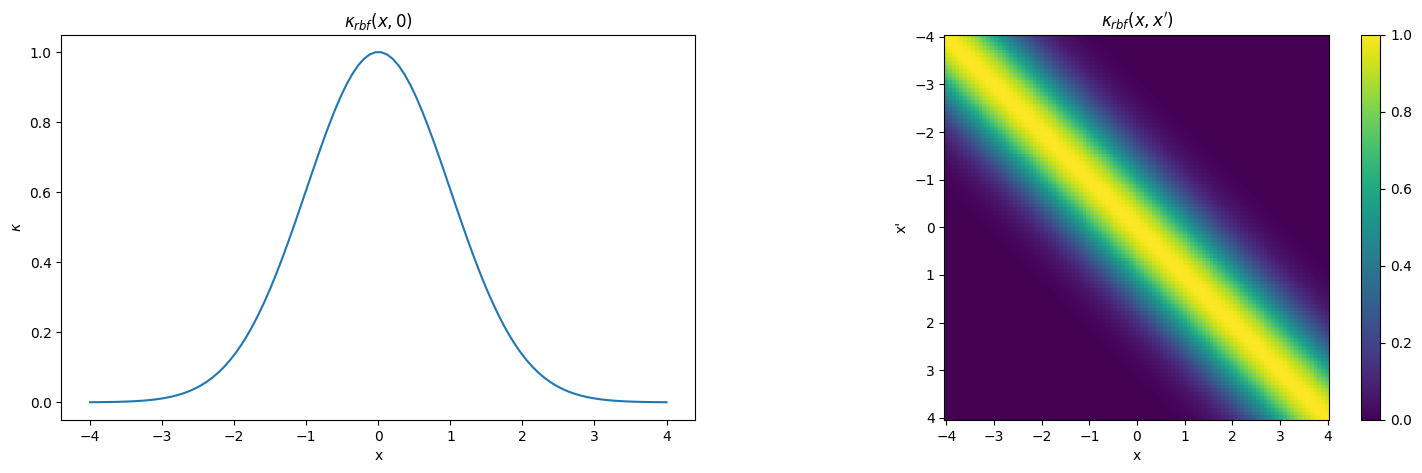

In [5]:
# Our sample space: 100 samples in the interval [-4,4]
X = np.linspace(-4.,4.,100)[:, None] # we need [:, None] to reshape X into a column vector for use in GPy

# Set up the plotting environment
plt.figure(figsize=(18,5))

# ==== k(x,0)

plt.subplot(121) # left plot

# First, sample kernel at x' = 0
K = k.K(X, np.array([[0.]])) # k(x,0)

# Plot covariance vector
plt.plot(X,K)

# Annotate plot
plt.xlabel("x"), plt.ylabel("$\kappa$")
plt.title("$\kappa_{rbf}(x,0)$")

# ==== k(x,x')

plt.subplot(122) # right plot

# The kernel takes two inputs, and outputs the covariance between each respective point in the two inputs
K = k.K(X,X)

# Plot the covariance of the sample space
plt.pcolor(X.T, X, K)

# Format and annotate plot
plt.gca().invert_yaxis(), plt.gca().axis("image")
plt.xlabel("x"), plt.ylabel("x'"), plt.colorbar()
plt.title("$\kappa_{rbf}(x,x')$");

## 7. Real World Example

We'll consider now a classic real world example using atmospheric $\mathrm{CO}_{2}$ observations from the Mauna Loa Observatory, Hawaii. The dataset is a good demonstration of the predictive power of Gaussian processes, and we will use it to show how we can encode our prior beliefs to combine kernels.

First, we need to download the dataset.

In [6]:
import pickle
import requests

# Load in the data
req = requests.get('https://github.com/gpschool/labs/raw/2023/.resources/mauna_loa')
data = pickle.loads(req.content)

print("\nData keys:")
print(data.keys())

print("\nCitation:")
print(data['citation'])

print("\nInfo:")
print(data['info'])


Data keys:
dict_keys(['X', 'Y', 'Xtest', 'Ytest', 'info', 'citation', 'details', 'files', 'license', 'size', 'urls'])

Citation:
Mauna Loa Data. Dr. Pieter Tans, NOAA/ESRL (www.esrl.noaa.gov/gmd/ccgg/trends/) and Dr. Ralph Keeling, Scripps Institution of Oceanography (scrippsco2.ucsd.edu/).

Info:
Mauna Loa data with 545 values used as training points.


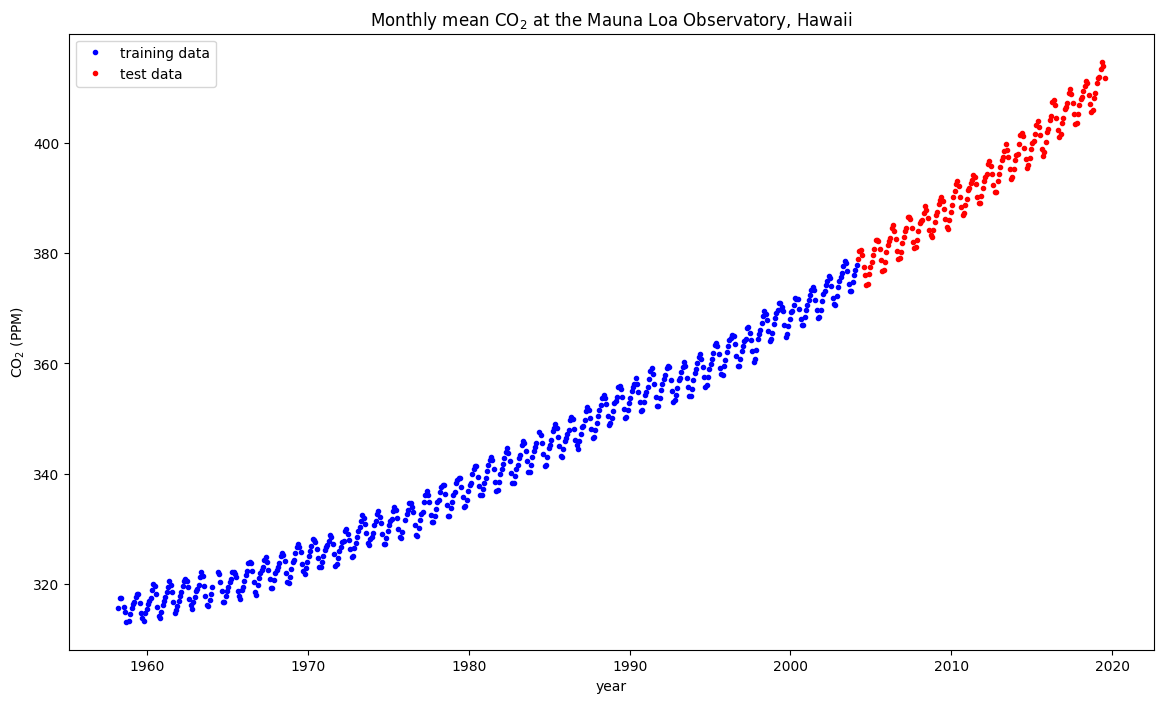

In [7]:
# Training data (X = input, Y = observation)
X, Y = data['X'], data['Y']

# Test data (Xtest = input, Ytest = observations)
Xtest, Ytest = data['Xtest'], data['Ytest']

# Set up our plotting environment
plt.figure(figsize=(14, 8))

# Plot the training data in blue and the test data in red
plt.plot(X, Y, "b.", Xtest, Ytest, "r.")

# Annotate plot
plt.legend(labels=["training data", "test data"])
plt.xlabel("year"), plt.ylabel("CO$_2$ (PPM)"), plt.title("Monthly mean CO$_2$ at the Mauna Loa Observatory, Hawaii");

**You may want to subsample the data to save time during the labs**

Run the following to reduce the datasize by only using every other training point:

In [8]:
X = X[::2, :]
Y = Y[::2, :]

### Naive GP regression

First, we will try to fit a basic RBF to our data, as we have used in previous examples

In [9]:
k = GPy.kern.RBF(1, name="rbf")

m = GPy.models.GPRegression(X, Y, k)
m.optimize()

m

GP_regression.,value,constraints,priors
rbf.variance,121454.97101823549,+ve,
rbf.lengthscale,101.50264382195351,+ve,
Gaussian_noise.variance,4.578100401385168,+ve,


In [10]:
def plot_gp(X, m, C, training_points=None):
    """ Plotting utility to plot a GP fit with 95% confidence interval """
    # Plot 95% confidence interval
    plt.fill_between(X[:,0],
                     m[:,0] - 1.96*np.sqrt(np.diag(C)),
                     m[:,0] + 1.96*np.sqrt(np.diag(C)),
                     alpha=0.5)
    # Plot GP mean and initial training points
    plt.plot(X, m, "-")
    plt.legend(labels=["GP fit"])

    plt.xlabel("x"), plt.ylabel("f")

    # Plot training points if included
    if training_points is not None:
        X_, Y_ = training_points
        plt.plot(X_, Y_, "kx", mew=2)
        plt.legend(labels=["GP fit", "sample points"])

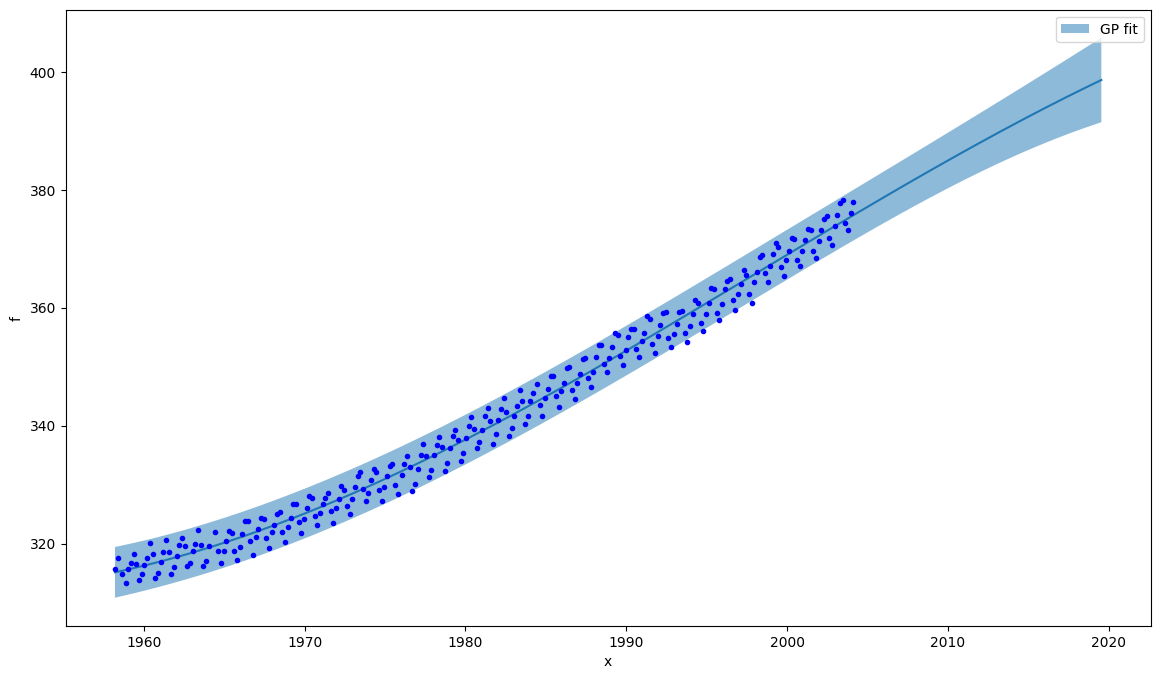

In [11]:
Xnew = np.vstack([X, Xtest])

mean, Cov = m.predict(Xnew, full_cov=True)

plt.figure(figsize=(14, 8))
plot_gp(Xnew, mean, Cov)
plt.plot(X, Y, "b.");

It is possible to make the model fit the data near perfectly by minimising the variance of the Gaussian noise in the likelihood and fixing the kernel variance.

In [12]:
# Effectively remove noise parameter (needs to be >0, so select value that is very low)
m.Gaussian_noise.variance = 0.00001
m.Gaussian_noise.variance.fix()

# We will fix the variance as well, so that only the lengthscale is optimised
m.rbf.variance = 10.
m.rbf.variance.fix()

# This should minimize the lengthscale to fit closely to the training points
m.optimize()
m

GP_regression.,value,constraints,priors
rbf.variance,10.0,+ve fixed,
rbf.lengthscale,9.718959703232983e-105,+ve,
Gaussian_noise.variance,1e-05,+ve fixed,


**But** this has no predictive power, and we have really just overfitted to the training data

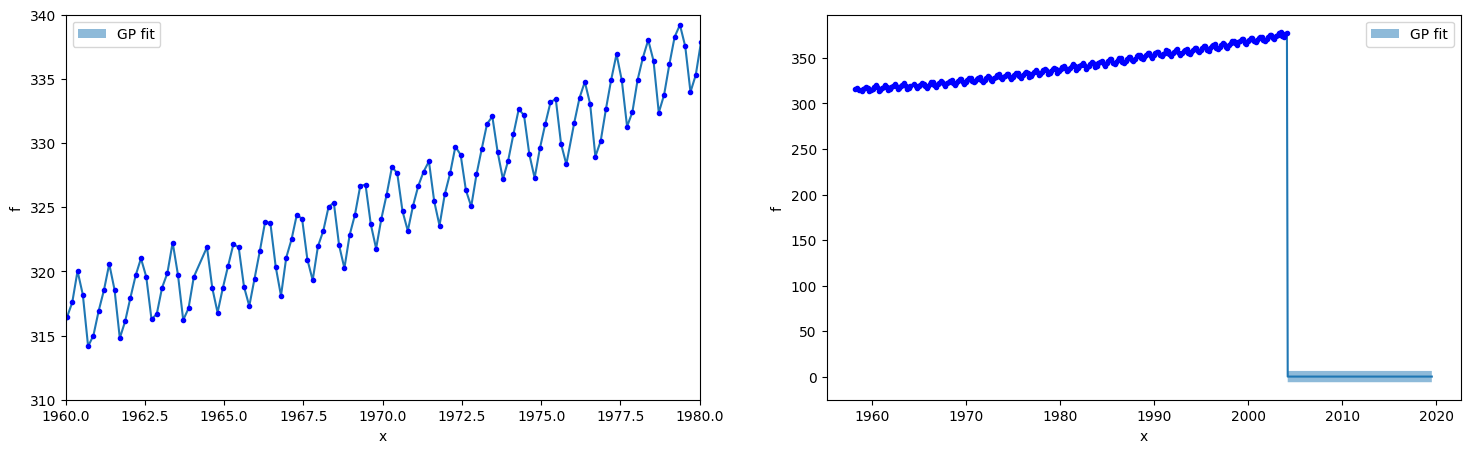

In [13]:
mean, Cov = m.predict(Xnew, full_cov=True)

plt.figure(figsize=(18, 5))

# The left plot shows the GP fit to a subsample of our training set
plt.subplot(121)
plot_gp(Xnew, mean, Cov)
plt.plot(X, Y, "b.");
plt.gca().set_xlim([1960,1980]), plt.gca().set_ylim([310, 340])

# The right plot shows that the GP has no predictive power and reverts to 0
plt.subplot(122)
plot_gp(Xnew, mean, Cov)
plt.plot(X, Y, "b.");

### GP Regression with combined covariance functions

Taking a look at the training data, we can see a number of features that occur in the data. There is a clear periodic trend that is yearly, and an approximately linear trend. We can use this prior information in our choice of kernel to give some meaning to the GP fit.

First, we will look at the linear trend. It should be obvious that the overall trend (ignoring the periodicity) can be described approximately by $f(x) \approx a + bx$. To embed this as a covariance function, we can use the  `Linear` covariance functions, which adds a linear trend to the covariance.

### Exercise 1

(a) Create a `Linear` kernel with reasonable estimates of the parameters that represent the trend? To create the Kernel consider the class GPy.kern.Linear.

In [14]:
k_L = GPy.kern.Linear(1, variances=[1.])

(b) How might we encode this trend in the mean estimate of the GP ?

Use a mapping function to represent the linear trend. We can hard code the parameters (gradient and intercept), or give them priors.

(c) Create a GP regression model using the kernels to fit the data. Comment on good is the fit and the predictive power of the model?. To create new kernels in GPy is as simple as summing or multiplying the clases, i.e., GPy.kern.RBF(1, active_dims=[0]) + GPy.kern.Matern32(1, active_dims=[1]) or GPy.kern.RBF(1, active_dims=[0]) * GPy.kern.Matern32(1, active_dims=[1])

GP_regression.,value,constraints,priors
sum.linear.variances,1.0,+ve,
sum.bias.variance,360.0,+ve,
Gaussian_noise.variance,1.0,+ve,


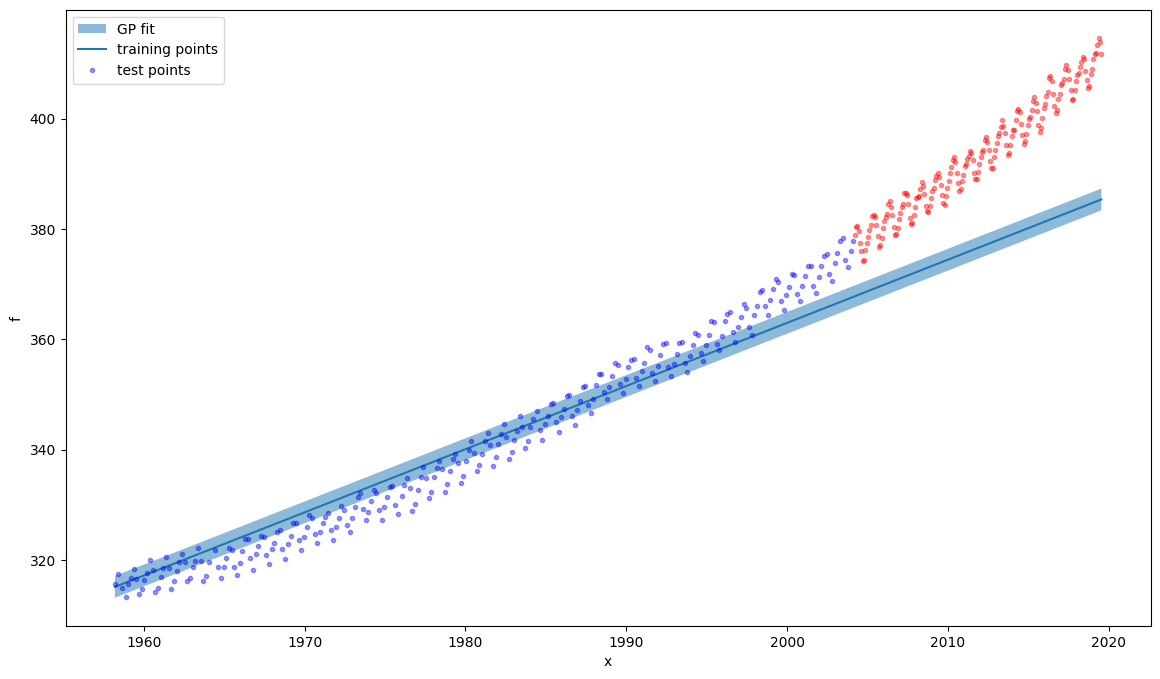

In [15]:
# Linear covariance function
m1 = GPy.models.GPRegression(
    X, Y,
    kernel = GPy.kern.Linear(1, variances=[1.]) + GPy.kern.Bias(1, 360)
)

mean, Cov = m1.predict(Xnew)

plt.figure(figsize=(14,8))
plot_gp(Xnew, mean, Cov)
plt.plot(X, Y, ".b", Xtest, Ytest, ".r", alpha=0.4);
plt.legend(labels=["GP fit","training points", "test points"])

display(m1)

### Periodicity

There is a seasonal trend over the year, and that a simple linear fit cannot capture this information. However, we can add this using our choice of kernel by adding a `StdPeriodic` kernel to our regression model. It's evident to the data that the period is yearly, so a period of $\omega=1$ is a sensible choice for our initial parameter:

GP_regression.,value,constraints,priors
sum.bias.variance,12469.074315737267,+ve,
sum.linear.variances,21243.458384421814,+ve,
sum.std_periodic.variance,209797.0507590762,+ve,
sum.std_periodic.period,0.9982033114152129,+ve,
sum.std_periodic.lengthscale,1487.1542276540508,+ve,
Gaussian_noise.variance,4.789585960733478,+ve,


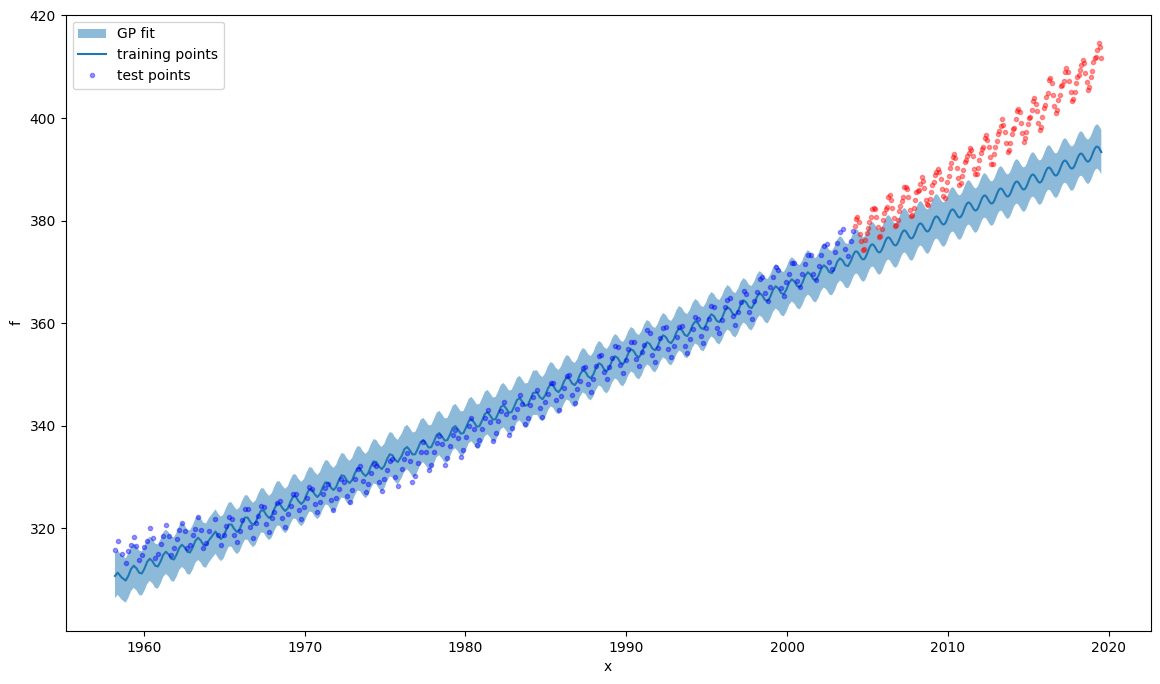

In [16]:
ks = [ # Our kernels
    GPy.kern.Bias(1, variance=10000.),    # Constant offset
    GPy.kern.Linear(1),                   # Linear trend
    GPy.kern.StdPeriodic(1, period=1)     # Periodicity
]

# Create a regression model with an additive kernel (bias + linear + periodic)
m = GPy.models.GPRegression(X, Y, ks[0] + ks[1] + ks[2])

# Optimise hyperparameters to maximise likelihood
m.optimize()

# Predict the value of CO2 using our GP fit
mean, Cov = m.predict(Xnew)

# Set up plotting
plt.figure(figsize=(14,8))

# Plot GP fit
plot_gp(Xnew, mean, Cov)
# Show our training and test points
plt.plot(X, Y, ".b", Xtest, Ytest, ".r", alpha=0.4)
# Annotate plot
plt.legend(labels=["GP fit","training points", "test points"])

# Preview the parameters of our model
m

From the plot we can see that while we have maintained the periodicity in our prediction, there is some deviation in the amplitude of each period. Likewise, the data is not strictly linear. We can embed model these non-linearities and deviations by adding an `Exponential` kernel. First, in the summative kernel, but also by multiplying a Gaussian RBF by the periodic kernel. For some intiution on how this allows for deviation of the periodicity, see the corresponding sample plot in Section 4.

Note that the `Exponential` kernel describes an exponential decay in covariance with distance between points, and does **not** model an exponential trend in the overall data. The `RBF` kernel describes a smoother (Gaussian) decay, which may be a better model for changes in the periodic signal.

In [17]:
ks = [ # Our kernels
    GPy.kern.Exponential(1),              # Non-linearity in overall trend
    GPy.kern.Bias(1, variance=10000.),    # Constant offset
    GPy.kern.Linear(1),                   # Linear trend
    GPy.kern.StdPeriodic(1, period=1.),   # Periodicity (short term trend)
    GPy.kern.RBF(1)                       # Amplitude modulator (long term trend)
]

# Composite kernel: exponential + bias + linear + (periodic * rbf)
k = ks[0] + ks[1] + ks[2] + ks[3]*ks[4]
k

sum.,value,constraints,priors
Exponential.variance,1.0,+ve,
Exponential.lengthscale,1.0,+ve,
bias.variance,10000.0,+ve,
linear.variances,1.0,+ve,
mul.std_periodic.variance,1.0,+ve,
mul.std_periodic.period,1.0,+ve,
mul.std_periodic.lengthscale,1.0,+ve,
mul.rbf.variance,1.0,+ve,
mul.rbf.lengthscale,1.0,+ve,


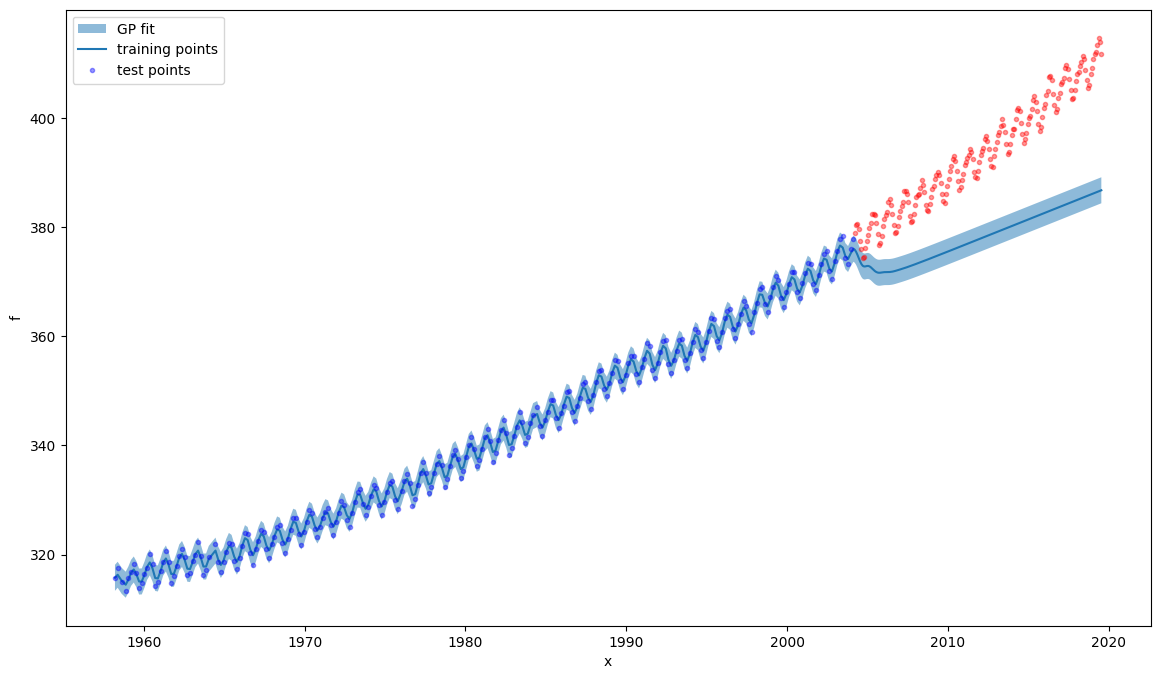

In [18]:
# Create our GP regression model with the composite kernel
m = GPy.models.GPRegression(X, Y, k)

# Predict the CO2 at the training and test locations
mean, Cov = m.predict(Xnew)

# Setup figure
plt.figure(figsize=(14,8))

# Plot the GP fit and training points
plot_gp(Xnew, mean, Cov)
plt.plot(X, Y, ".b", Xtest, Ytest, ".r", alpha=0.4);

# Annotate plot
plt.legend(labels=["GP fit","training points", "test points"]);

We can see that with even with our initial (mostly default) parameter choices, the GP fit to the training data is representative of the trends we are observing. However, the prediction of the test data is relatively poor (though we still have an upward trend). The obvious step now is to optimise our kernel parameters.

Optimisation of the GP in itself is imperfect, often because the likelihood we are maximising can be multimodal, or flat, and so it can get stuck in local-maxima. It is always important to sanity-check the GP fit when optimising the parameters, to mitigate problems that could occur as a result (such as the minimised noise example we saw earlier). One of the ways to avoid the problem of local maxima is to reinitialise the optimiser with different starting locations, and take the maximum of these outputs. This is possible in `GPy` using `optimize_restarts(n)`, which will optimise the parameters $n$ times and take the best estimate.

Optimization restart 1/5, f = 150.48378375419802
Optimization restart 2/5, f = 715.6794581040323
Optimization restart 3/5, f = 149.70751034466116
Optimization restart 4/5, f = 138.8708322180774
Optimization restart 5/5, f = 316.4676542246255


GP_regression.,value,constraints,priors
sum.Exponential.variance,2.4225280822156012,+ve,
sum.Exponential.lengthscale,15.734423943100474,+ve,
sum.bias.variance,2.643830854391744,+ve,
sum.linear.variances,0.07894148173265261,+ve,
sum.mul.std_periodic.variance,194.653147457487,+ve,
sum.mul.std_periodic.period,0.9994327137721049,+ve,
sum.mul.std_periodic.lengthscale,5.009332302567589,+ve,
sum.mul.rbf.variance,178.12964353662622,+ve,
sum.mul.rbf.lengthscale,150.27398996529774,+ve,
Gaussian_noise.variance,0.03862205801121305,+ve,


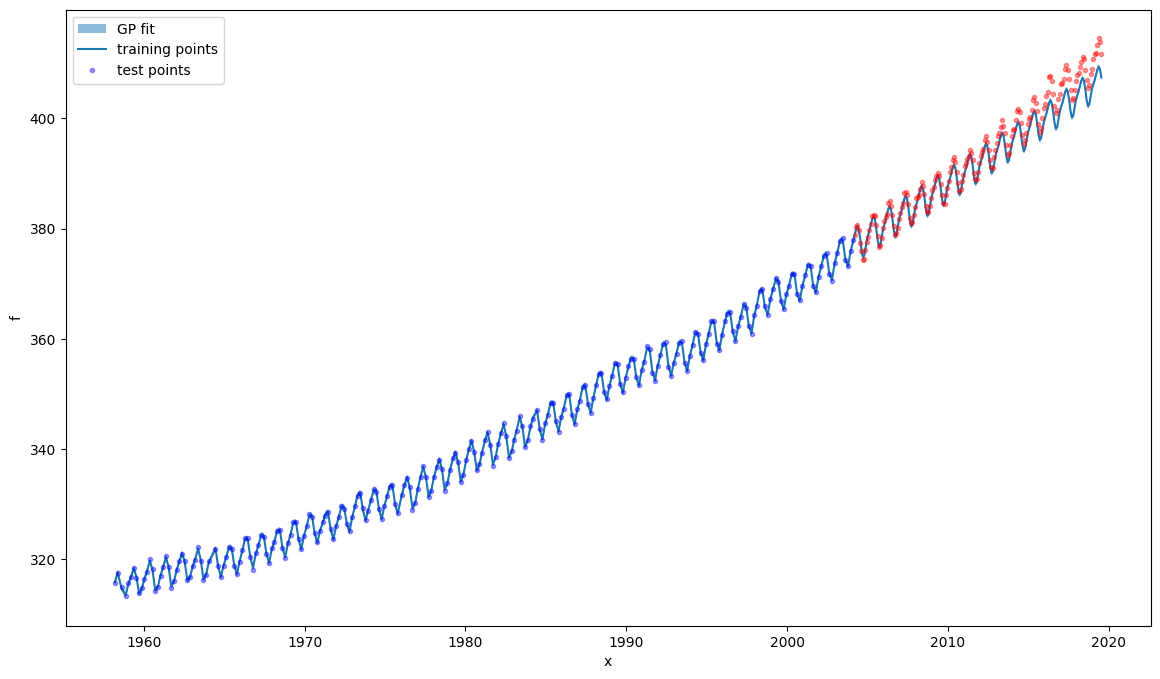

In [19]:
# Optimise hyperparameters 5 times to get a good estimate
m.optimize_restarts(5, robust=True) # We could do this more times, but it can be quite time consuming

# Get the moments of our model fit
mean, Cov = m.predict(Xnew)

# Set up plot environment
plt.figure(figsize=(14,8))

# Plot our optimised GP and training/test points
plot_gp(Xnew, mean, Cov)
plt.plot(X, Y, ".b", Xtest, Ytest, ".r", alpha=0.4);
# Annotate plot
plt.legend(labels=["GP fit","training points", "test points"])
# Preview model parameters
m

We can see from the output of the optimiser that there are a number of different minima in the negative log-likelihood (corresponding to maxima in the likelihood), implying that there are several modes. However, it's possible to get a good fit of the function with a GP with great predictive power. You might try allowing the optimiser to run for more iterations when you have more time.

We can also look at the effects of each kernel on the GP model, which will show the features that it represents in the fit. For example, we expect the `Bias` to capture the offset, and the `Exponential` kernel to extract most of the non-linearity (that's not explained by the periodicity). We can view the effects of each of the components and the combination of them to see how they deconstruct the training data. This shows what features are being learned by which kernel.

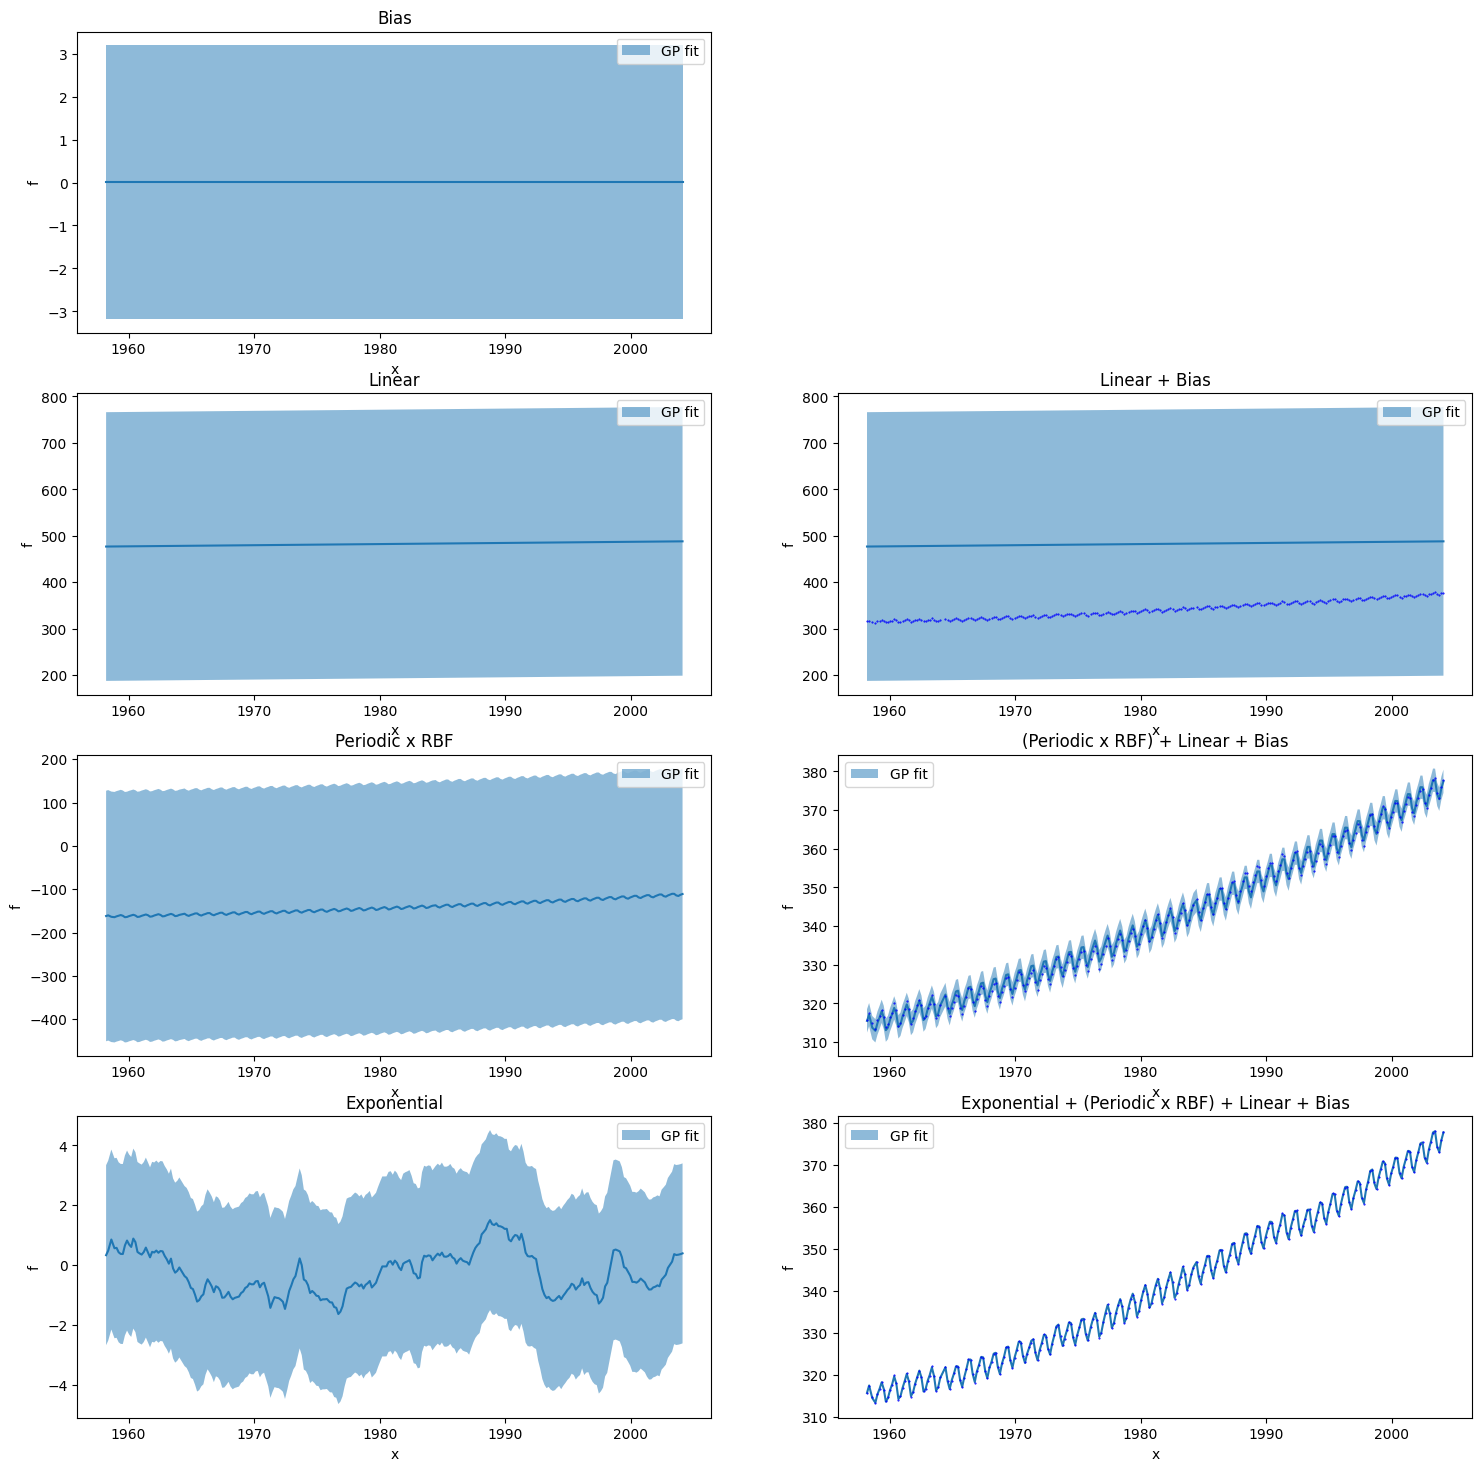

In [20]:
# Setup figure environment (4x2 grid)
plt.figure(figsize=(18,18))

# Show Bias kernel effect
plt.subplot(421)
mean, Cov = m.predict_noiseless(X, kern=m.sum.bias)
plot_gp(X, mean, Cov)
plt.title("Bias")

# Show Linear kernel effect
plt.subplot(423)
mean, Cov = m.predict_noiseless(X, kern=m.sum.linear)
plot_gp(X, mean, Cov)
plt.title("Linear")

# Show combination of Bias and Linear kernels
plt.subplot(424)
mean, Cov = m.predict_noiseless(X, kern=m.sum.linear + m.sum.bias)
plot_gp(X, mean, Cov)
plt.plot(X, Y, ".b", ms=1.)
plt.title("Linear + Bias")

# Show modulated Periodic x RBF kernel
plt.subplot(425)
mean, Cov = m.predict_noiseless(X, kern=m.sum.mul)
plot_gp(X, mean, Cov)
plt.title("Periodic x RBF")

# Show combination of Periodic, Bias and Linear kernels
plt.subplot(426)
mean, Cov = m.predict_noiseless(X, kern=m.sum.mul + m.sum.linear + m.sum.bias)
plot_gp(X, mean, Cov)
plt.plot(X, Y, ".b", ms=1.)
plt.title("(Periodic x RBF) + Linear + Bias")

# Show Exponential kernel effect
plt.subplot(427)
mean, Cov = m.predict_noiseless(X, kern=m.sum.Exponential)
plot_gp(X, mean, Cov)
plt.title("Exponential")

# Show combination of Periodic, Bias, Linear and Exponential kernel (this is our full GP fit !)
plt.subplot(428)
mean, Cov = m.predict_noiseless(X, kern=m.sum.Exponential + m.sum.mul + m.sum.linear + m.sum.bias)
plot_gp(X, mean, Cov)
plt.plot(X, Y, ".b", ms=1.)
plt.title("Exponential + (Periodic x RBF) + Linear + Bias");

It's clear that while our final fit is very good, some of the kernel effects are not as clear cut as we expected. For example, much of the upward trend is captured by the periodic combination, likely due to its ability to vary non-linearly. However, we can see that, for example, the `Exponential` kernel has a clear purpose in adjusting the GP fit to the data.

### Exercise 2

What improvements might be made to the GP model, for example in terms  combinations of kernels and parameters, to get a better fit, especially for the prediction of our testing data?

How clear the differing effects of the kernels are is dependent on the random seed, and the number of optimisation restarts of the hyperparameters. However something that can be observed is that trying to embed the linear trend in the covariance function with a nonlinear periodic function is largely redundant as the periodic*rbf kernel is clearly capturing most of the upward trend. We might play around with smoother non-linear kernels, for example adding a higher order Matern than exponential (3/2 or 5/2). We can also make use of kernels not shown in this lab, such as the periodic Matern kernels.

Another option is to embed our linear trend in the mean function of our GP prior. While this is not especially common in machine learning, if we have reliable prior assumptions of the model, we can embed this explicitly. Putting a prior over the parameters of the linear mean function would keep the Bayesian approach to learning the model, but would allow us to fit periodicity to the data independent(ish) of the linear mapping.

## 8. Multiple Inputs

Typically, we will have data that is more than one-dimensional. Gaussian processes regression is scalable in dimension, and everything used above can be used with multiple inputs. The following problem is reasonably straight-forward, a simple extension of the regression problem we've used to 2-dimensional input.

Consider the toy example:
$$
    f = (x_1, x_2) \mapsto \sin(x_1)\sin(x_2)
$$
$$
    y = f(\mathbf{X}) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)
$$

Now, our input space is made up of two coordinates, $(x_1, x_2)$. Suppose we have some random noisy observations of the function, which are 1-dimensional in nature:

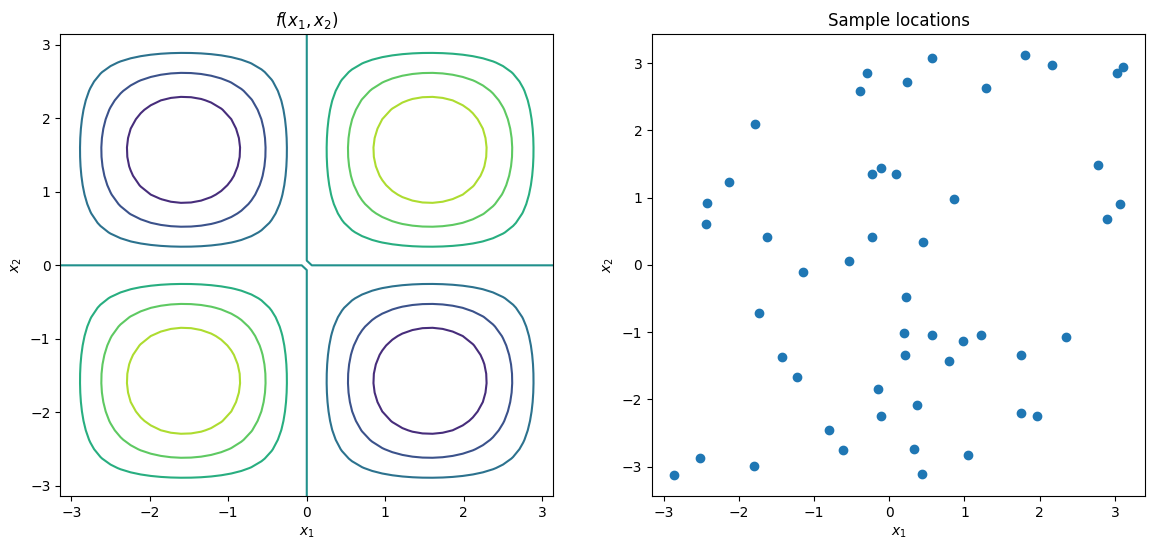

In [21]:
# Lambda function, f, the unknown function we are trying to predict
f = lambda xi,xj: np.sin(xi) * np.sin(xj)

# Our test grid
[Xi, Xj] = np.meshgrid(np.linspace(-np.pi, np.pi, 50), np.linspace(-np.pi, np.pi, 50))

# Number of samples [YOU CAN PLAY AROUND WITH THE NUMBER OF RANDOM SAMPLES TO SEE HOW THE FIT IS AFFECTED]
num_measurements = 50

# Random sample locations (2-D)
X2 = np.random.uniform(-np.pi, np.pi, (num_measurements, 2))

# Setup plot enviornment
plt.figure(figsize=(14, 6))

plt.subplot(121)
# Show true function
plt.contour(Xi, Xj, f(Xi,Xj))
# Annotate plot
plt.xlabel("$x_1$"), plt.ylabel("$x_2$")
plt.title("$f(x_1,x_2)$")

plt.subplot(122)
# Show sample locations
plt.plot(X2[:,0],X2[:,1],'o')
# Annotate plot
plt.xlabel("$x_1$"), plt.ylabel("$x_2$")
plt.title("Sample locations");

Our observations then are simply our sample locations propagated through $f$ with some Gaussian noise

In [22]:
Y2 = np.array([f(x1,x2) for (x1,x2) in zip(X2[:,0], X2[:,1])])[:,None] + 0.05 * np.random.randn(X2.shape[0], 1)

We can fit a Gaussian process over the observations by selecting a 2-D kernel. For example, the `RBF` kernel has a 2-D (really N-D) form, so we can use this as our kernel choice. Here we need to set both the `input_dim` to `2`, and specify the dimensions of the data we want the kernel to act over. In this case, it is the first 2 (of 2) dimensions, which in Python are indexed by `0` and `1`.

GP_regression.,value,constraints,priors
rbf.variance,0.22381088017412817,+ve,
rbf.lengthscale,1.381236017693655,+ve,
Gaussian_noise.variance,0.05,+ve fixed,


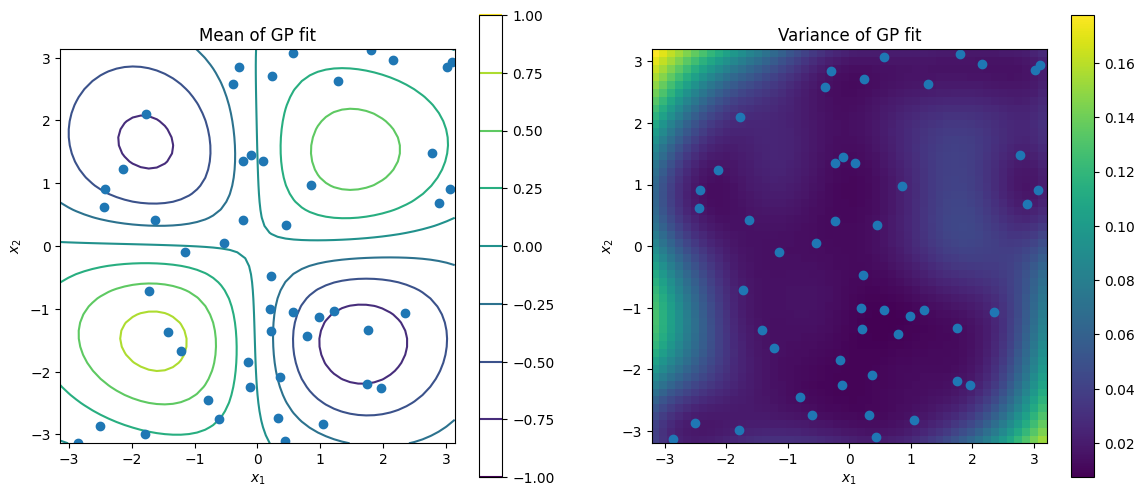

In [23]:
# Create a 2-D RBF kernel active over both input dimensions
k = GPy.kern.RBF(2, active_dims=[0,1])

# Create a GP Regression model with the sample locations and observations using the RBF kernel
m = GPy.models.GPRegression(X2, Y2, k)

# Fix the Gaussian noise variance, which we know
m.Gaussian_noise.variance = 0.05
m.Gaussian_noise.variance.fix()

# Optimise the kernel parameters
m.optimize()

# We need to augument our test space to be a list of coordinates for input to the GP
Xnew2 = np.vstack((Xi.ravel(), Xj.ravel())).T # Change our input grid to list of coordinates

# Predict the mean and covariance of the GP fit at the test locations
mean2, Cov2 = m.predict_noiseless(Xnew2, full_cov=False)

# Setup plot environment
plt.figure(figsize=(14, 6))

# Left plot shows mean of GP fit
plt.subplot(121)

# Plot mean surface
plt.contour(Xi, Xj, mean2.reshape(Xi.shape))
# Show sample locations
plt.plot(X2[:,0],X2[:,1],'o'), plt.axis("square")
# Annotate plot
plt.xlabel("$x_1$"), plt.ylabel("$x_2$")
plt.title("Mean of GP fit"), plt.colorbar()

# Right plot shows the variance of the GP
plt.subplot(122)
# Plot variance surface
plt.pcolor(Xi, Xj, Cov2.reshape(Xi.shape))
# Show sample locations
plt.plot(X2[:,0],X2[:,1],'o'), plt.axis("square")
# Annotate plot
plt.xlabel("$x_1$"), plt.ylabel("$x_2$")
plt.title("Variance of GP fit"), plt.colorbar()

# Preview GP model parameters
m

We can see here that the fit with the GP is generally good (this is quite a simple example, after all), and that functionally, the setup is almost identical to the 1-D case using `GPy`. We can also observe from the variance surface that we have the most uncertainty where there are no samples, which matches our expectations and the observation of the power of GPs in 1-D.

Notice that in the model preview, we only have a single lengthscale that is based on both dimensions. This is because by default, the RBF kernel is isotropic, which in our case is fine. However, in reality, it is often desirable to have different parameters corresponding to different dimensions. There are two approaches to doing this in `GPy`. The first is to enable different anisotropy within the kernel itself, by using the `ARD` keyword, e.g.
```
k = GPy.kern.RBF(2, ARD=True)
```

Alternatively, we can use kernel composition to create two kernels acting seperately on different dimensions. An alternative construction of the anisotropic RBF is to construct a kernel from two 1-D `RBF` kernels active on $x_1$ and $x_2$ respectively:
```
k = GPy.kern.RBF(1, active_dims=[0]) * GPy.kern.RBF(1, active_dims=[1])
```

We can also use this construction to allow for different covariance assumptions in different dimensions. In the following example, we use an RBF to model $x_1$ and a Matérn 3/2 kernel for $x_2$:
```
k = GPy.kern.RBF(1, active_dims=[0]) * GPy.kern.Matern32(1, active_dims=[1])
```

GP_regression.,value,constraints,priors
mul.rbf.variance,0.4567675306685008,+ve,
mul.rbf.lengthscale,1.4481591240805707,+ve,
mul.Mat32.variance,0.4567675306685006,+ve,
mul.Mat32.lengthscale,1.6032981969663398,+ve,
Gaussian_noise.variance,0.05,+ve fixed,


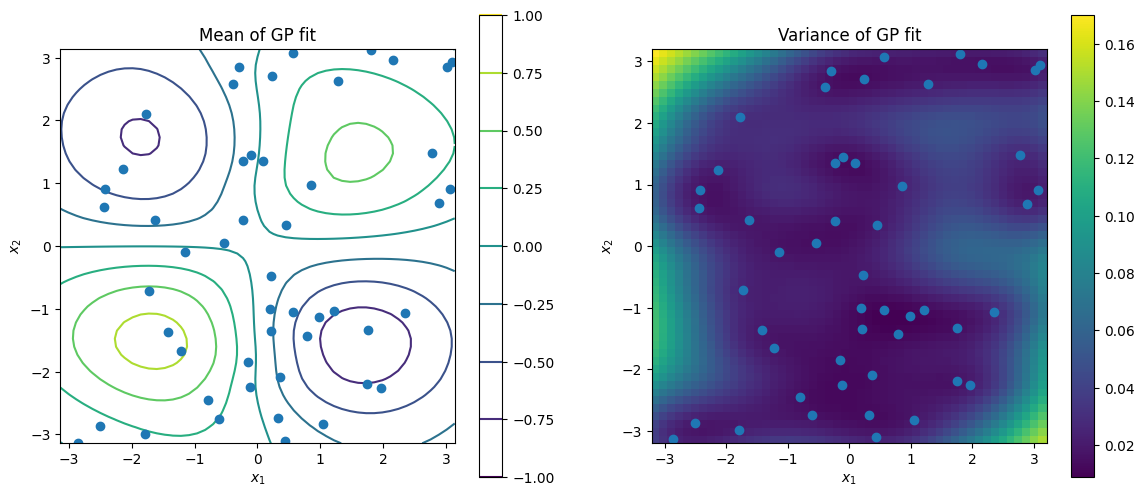

In [24]:
# Construct a 2-D kernel with two 1-D kernels: RBF and Matern32
k = GPy.kern.RBF(1, active_dims=[0]) * GPy.kern.Matern32(1, active_dims=[1])

# Create a GP regression model with our 2-D composite kernel
m = GPy.models.GPRegression(X2, Y2, k)

# Fix the Gaussian noise variance
m.Gaussian_noise.variance = 0.05
m.Gaussian_noise.variance.fix()

# Optimise the kernel parameters
m.optimize()

# Change our input grid to list of coordinates
Xnew2 = np.vstack((Xi.ravel(), Xj.ravel())).T

# Predict the mean and covariance function
mean2, Cov2 = m.predict_noiseless(Xnew2, full_cov=False)

# Setup figure environment
plt.figure(figsize=(14, 6))

# Plot mean on left
plt.subplot(121)

# Plot mean surface
plt.contour(Xi, Xj, mean2.reshape(Xi.shape))
# Plot sample locations
plt.plot(X2[:,0],X2[:,1],'o'), plt.axis("square")
# Annotate plot
plt.xlabel("$x_1$"), plt.ylabel("$x_2$")
plt.title("Mean of GP fit"), plt.colorbar()

# Show variance on right
plt.subplot(122)

# Plot variance surface
plt.pcolor(Xi, Xj, Cov2.reshape(Xi.shape))
# Plot sample locations
plt.plot(X2[:,0],X2[:,1],'o'), plt.axis("square")
# Annotate plot
plt.xlabel("$x_1$"), plt.ylabel("$x_2$")
plt.title("Variance of GP fit"), plt.colorbar()

# Preview model parameters
m

---

## Footnote

Using Gaussian processes for machine learning gives you a powerful tool for learning latent functions in a Bayesian fashion, especially with a low number of observations. However, full GP regression can be quite time consuming, given it scales $\mathscr{O}(n^3)$ with the number of training points, $n$. There are methods for dealing with this: for example, sparse approximation or representing the regression problem as a state-space model. Each of these comes with their own assumptions and drawbacks. In tomorrow's session, there will be a lecture on computational efficiency in GPs and the next lab will have examples of some of these approaches.

When using GPs in a computational setting, there are a wide range of tools that can be used depending on your preference of programming language and libraries. `GPy`, the library we use in these labs, is a well established Python library that was developed here at the University of Sheffield, and is maintained by members here and at Amazon Research Cambridge. Some other libraries that are commonly used for Gaussian processes include:

| Name     | Language | Comments |
|---------|-----------|----------|
| `GPy`     | Python | One of the earliest Python frameworks for Gaussian processes |
| `GPML`    | MATLAB | Examples and code used in Rasmussen & Williams GPML book |
| `GPstuff` | MATLAB, Octave, R | A MATLAB library with a wide arrange of inference methods, including HMC |
| `GPflow`  | Python | GP library built on `TensorFlow`, similar notation to `GPy` |
| `GPyTorch` | Python | GP library built on `PyTorch` |
| `Stan`    | R, Python, others | Probabilistic programming using MCMC that can be easily be used to model GPs |